# This notebook is to test the actual NumPy-based and cuPyNumeric-based implementations of ExactBO

In [1]:
import tamubo.exactbo as ebo
import tamubo.utils as utils
import tamubo.acquisition_functions as acqfun
import cupynumeric as cp
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.patches import Rectangle
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

## 1 -  Check Expected Improvement

In [4]:
cpmu = cp.array([0.1, 0.2, 0.3])
cpsigma = cp.array([0.1, 0.2, 0.3])

npmu = np.array([0.1, 0.2, 0.3])
npsigma = np.array([0.1, 0.2, 0.3])

ymin = 0.0

cpei = acqfun.expected_improvement(cpmu, cpsigma, ymin)
#npei = ebo.expected_improvement(npmu, npsigma, ymin)

In [5]:
cpei

array([0.00833155, 0.01666309, 0.02499464])

In [6]:
tempcpei = acqfun.expected_improvement(cpmu, cpsigma, ymin, backend="cupynumeric")
tempnpei = acqfun.expected_improvement(npmu, npsigma, ymin, backend="numpy")

In [7]:
tempcpei, tempnpei

(array([0.00833155, 0.01666309, 0.02499464]),
 array([0.00833155, 0.01666309, 0.02499464]))

## 2 -  Check Backend

In [8]:
utils.resolve_backend()

BackendInfo(requested='auto', selected='cupynumeric', cupynumeric_available=True)

## 3 - Check Partitioning

### 3.1 - Simple

#### 3.1.1 - 2D

In [2]:
def plot_rectangles(bounds_L, bounds_U, pad=0.01):
    bounds_L = np.asarray(bounds_L)
    bounds_U = np.asarray(bounds_U)
    assert bounds_L.shape == bounds_U.shape and bounds_L.shape[1] == 2

    widths = bounds_U[:, 0] - bounds_L[:, 0]
    heights = bounds_U[:, 1] - bounds_L[:, 1]

    inset_ll = bounds_L + pad
    inset_w = np.maximum(widths - 2 * pad, 0)
    inset_h = np.maximum(heights - 2 * pad, 0)

    fig, ax = plt.subplots()
    for (x, y), w, h in zip(inset_ll, inset_w, inset_h):
        ax.add_patch(Rectangle((x, y), w, h,
                               fill=False,
                               linewidth=2.0,
                               edgecolor='C0'))
    ax.set_aspect('equal', adjustable='box')
    ax.autoscale_view()
    plt.show()

In [8]:
bounds_L = np.array([[0.0, 0.0], 
                     [0.4, 0.7]])

bounds_U = np.array([[0.3, 0.9], 
                     [1.0, 1.0]])

active_boxes_mask = np.array([True, True])

w = np.array([1, 1])
n = 2
d = 2

bounds_L_np, bounds_U_np = ebo.split_boxes(bounds_L, bounds_U, active_boxes_mask, w, n, d, backend="numpy")
bounds_L_cp, bounds_U_cp = ebo.split_boxes(bounds_L, bounds_U, active_boxes_mask, w, n, d)

In [9]:
bounds_L_np == bounds_L_cp

array([[ True,  True],
       [ True,  True],
       [ True,  True],
       [ True,  True],
       [ True,  True],
       [ True,  True],
       [ True,  True],
       [ True,  True],
       [ True,  True],
       [ True,  True]])

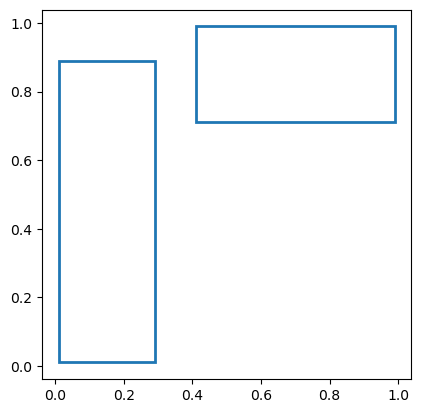

In [10]:
plot_rectangles(bounds_L, bounds_U)

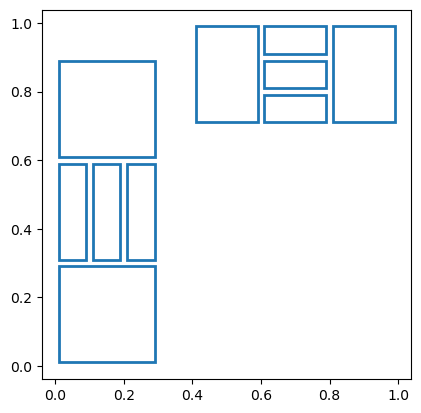

In [11]:
plot_rectangles(bounds_L_np, bounds_U_np)

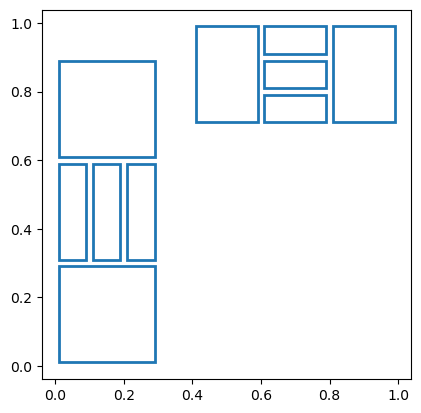

In [12]:
plot_rectangles(bounds_L_cp,bounds_U_cp)

#### 3.1.2 - 3D

In [13]:
def plot_cubes(bounds_L, bounds_U, pad=0.01):
    bounds_L = np.asarray(bounds_L, dtype=float)
    bounds_U = np.asarray(bounds_U, dtype=float)
    assert bounds_L.shape == bounds_U.shape and bounds_L.ndim == 2 and bounds_L.shape[1] == 3

    pad = np.asarray(pad, dtype=float)
    pad = np.full(3, pad) if pad.ndim == 0 else np.broadcast_to(pad, (3,))

    sizes = bounds_U - bounds_L
    inset_ll = bounds_L + pad
    inset_size = np.maximum(sizes - 2 * pad, 0.0)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")

    for (x, y, z), (dx, dy, dz) in zip(inset_ll, inset_size):
        x1, y1, z1 = x + dx, y + dy, z + dz

        v000 = [x,  y,  z]
        v100 = [x1, y,  z]
        v110 = [x1, y1, z]
        v010 = [x,  y1, z]
        v001 = [x,  y,  z1]
        v101 = [x1, y,  z1]
        v111 = [x1, y1, z1]
        v011 = [x,  y1, z1]

        faces = [
            [v000, v100, v110, v010],  # bottom
            [v001, v101, v111, v011],  # top
            [v000, v100, v101, v001],  # front
            [v010, v110, v111, v011],  # back
            [v000, v010, v011, v001],  # left
            [v100, v110, v111, v101],  # right
        ]

        ax.add_collection3d(
            Poly3DCollection(
                faces,
                facecolors=(0, 0, 0, 0),  # transparent
                edgecolors="C0",
                linewidths=1.5,
            )
        )

    mins = inset_ll.min(axis=0)
    maxs = (inset_ll + inset_size).max(axis=0)
    span = np.maximum(maxs - mins, 1e-12)

    ax.set_xlim(mins[0], maxs[0])
    ax.set_ylim(mins[1], maxs[1])
    ax.set_zlim(mins[2], maxs[2])
    ax.set_box_aspect(span)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    plt.tight_layout()
    plt.show()


In [14]:
bounds_L = np.array([[0.0, 0.0, 0.0], 
                     [0.0, 0.0, 0.0],
                     [0.0, 0.0, 0.0], 
                     [0.0, 0.0, 0.0]])

bounds_U = np.array([[1.0, 3.0, 4.0], 
                     [1.0, 3.0, 2.0],
                     [2.0, 3.0, 1.0], 
                     [3.0, 1.0, 2.0]])

active_boxes_mask = np.array([True, True, True, True])

w = np.array([1, 1, 1])
n = 4
d = 3

bounds_L_np, bounds_U_np = ebo.split_boxes(bounds_L, bounds_U, active_boxes_mask, w, n, d, backend="numpy")
bounds_L_cp, bounds_U_cp = ebo.split_boxes(bounds_L, bounds_U, active_boxes_mask, w, n, d)

In [15]:
bounds_U_cp == bounds_U_np

array([[ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True]])

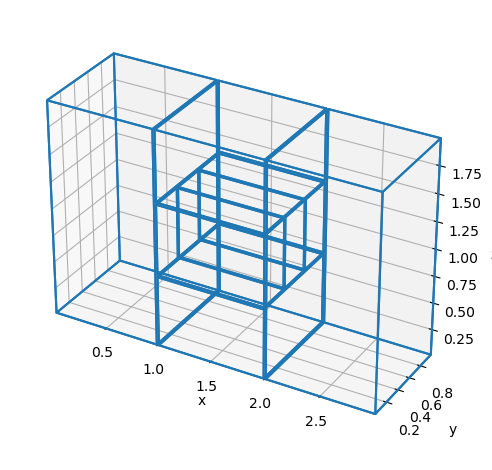

In [16]:
plot_cubes(bounds_L_cp[21:28], bounds_U_cp[21:28])

### 3.2 - Splitting Loop

#### 3.2.1 - Old version

In [29]:
import tamubo.exactbo as ebo
import cupynumeric as cp

bounds_L = cp.array([[0.0, 0.0]])
bounds_U = cp.array([[3**6/10, 3**6/10]])

w = cp.array([3**6/10, 3**6/10])
d = 2

BL, BU = [bounds_L],[bounds_U]
for i in range(12):
    n = bounds_L.shape[0]
    active_boxes_mask = cp.ones((n,), dtype=cp.bool_)
    if i > 0:
        active_boxes_mask[0] = False
    bounds_L, bounds_U = ebo.split_boxes(bounds_L, bounds_U, active_boxes_mask, w, n, d, validation=False)
    #bounds_L = cp.array(bounds_L, dtype=cp.float64, copy=True)
    #bounds_U = cp.array(bounds_U, dtype=cp.float64, copy=True)
    BL.append(bounds_L)
    BU.append(bounds_U)

In [30]:
len(BU[-1])

195312501

#### 3.2.2 - Memory Optimized Version

In [33]:
import tamubo.exactbo as ebo
import cupynumeric as cp

bounds_L = cp.array([[0.0, 0.0]])
bounds_U = cp.array([[3**6/10, 3**6/10]])

w = cp.array([3**6/10, 3**6/10])
d = 2

BLn, BUn = [bounds_L],[bounds_U]
for i in range(11):
    n = bounds_L.shape[0]
    active_boxes_mask = cp.ones((n,), dtype=cp.bool_)
    #if i > 0:
    #    active_boxes_mask[0] = False
    bounds_L, bounds_U = ebo.split_boxes(bounds_L, bounds_U, active_boxes_mask, w, n, d)
    #bounds_L = cp.array(bounds_L, dtype=cp.float64, copy=True)
    #bounds_U = cp.array(bounds_U, dtype=cp.float64, copy=True)
    BLn.append(bounds_L)
    BUn.append(bounds_U)

In [34]:
len(BLn[-1])

48828125

In [12]:
cp.all(BL[-1] == BLn[-1])

array(True)

#### 3.2.3 - New version analysis

In [33]:
d = 3
stride = 2 * d + 1
nt = 4

domain_width = cp.array([1.0,1.0,1.0])

active_width = cp.array([[1.0,3.0,4.0],
                        [1.0,3.0,2.0],
                        [2.0,3.0,1.0],
                        [3.0,1.0,2.0]])

active_width_prop = cp.divide(active_width, domain_width)

split_order = cp.argsort(active_width_prop, axis=1)
split_rank = cp.empty_like(split_order)

row_ids_2d = cp.arange(nt)[:,None]

split_rank[row_ids_2d, split_order] = cp.arange(d)[None, :]

row_ids = cp.arange(nt)
row_base = cp.arange(nt, dtype=cp.int64) * stride # (nt,)

cols = cp.empty(nt, dtype=cp.int64) # (nt,)
w_sel = cp.empty(nt, dtype=active_width.dtype) # (nt,)
lb = cp.empty(nt, dtype=active_width.dtype) # (nt,)
ub = cp.empty(nt, dtype=active_width.dtype) # (nt,)
rows_tmp = cp.empty(nt, dtype=cp.int64) # (nt,)

In [34]:
active_width

array([[1., 3., 4.],
       [1., 3., 2.],
       [2., 3., 1.],
       [3., 1., 2.]])

In [35]:
split_order

array([[0, 1, 2],
       [0, 2, 1],
       [2, 0, 1],
       [1, 2, 0]])

In [36]:
split_rank

array([[0, 1, 2],
       [0, 2, 1],
       [1, 2, 0],
       [2, 0, 1]])

In [37]:
dd = 0
cols[...] = split_rank[:, dd]
w_sel[...] = active_width[row_ids, cols]

In [39]:
cols, w_sel

(array([0, 0, 1, 2]), array([1., 1., 3., 2.]))

## 4 - Check bounds

### 4.1 - Native check

In [2]:
bounds_L = [[0.0, 0.0, 0.0],
            [0.4, 0.7, 0.1]]
bounds_U = [[0.3, 0.9, 0.6],
            [1.0, 1.0, 1.0]]
xi = [[0.1, 0.2, 0.3],
      [0.5, 0.5, 0.5],
      [0.9, 0.8, 0.7]]
n = 2
d = 3
sigma_f_2 = 0.01
length_scale = [0.5,0.25,0.125]

kernel_test = (ConstantKernel(sigma_f_2)*RBF(length_scale)+WhiteKernel(0.01))

In [3]:
kernel_test((np.array(bounds_L) + np.array(bounds_U))/2,xi[2:3])

array([[7.28152539e-06],
       [4.40431655e-03]])

In [4]:
K_lo_np, K_hi_np = ebo.rbf_k_bounds(bounds_L, bounds_U, xi[0], n, d, sigma_f_2, length_scale, backend="numpy")
K_lo_np, K_hi_np, type(K_lo_np), type(K_hi_np)

(array([1.02814405e-05, 1.83281114e-12]),
 array([0.01      , 0.00113042]),
 numpy.ndarray,
 numpy.ndarray)

In [5]:
K_lo_cp, K_hi_cp = ebo.rbf_k_bounds(bounds_L, bounds_U, xi[0], n, d, sigma_f_2, length_scale)
K_lo_cp, K_hi_cp, type(K_lo_cp), type(K_hi_cp)

(array([1.02814405e-05, 1.83281114e-12]),
 array([0.01      , 0.00113042]),
 cupynumeric._array.array.ndarray,
 cupynumeric._array.array.ndarray)

### 4.2 - Advanced check

In [19]:
# Define model
kernel = ConstantKernel(1.0, (1e-2, 1e3)) * RBF(length_scale=np.array([0.2,0.2]), length_scale_bounds=(1e-2, 10.0)) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-10, 1e1))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)

# Define bounds
bounds = np.array([[0,1],[0,1]])

# Function to minimize
# f(x,y)= \alpha(x^2 + y^2) - \sum_{i=1}^3 A_i \exp \left( -\frac{(x - Cx_i)^2 + (y - Cy_i)^2}{B_i} \right) + D
def f(X):
    if len(X.shape) == 1:
        X = X.reshape(1,-1)
        
    x, y = X[:,0], X[:,1]

    # Parameters
    alpha = 0.1
    A  = np.array([4, 3, 2])
    B  = np.array([0.08, 0.05, 0.02])    # betas
    C  = np.array([[0.9, 0.3 ],      # centers (x1,y1)
                [0.1 , 0.8],
                [0.6 , 0.7 ]])
    D = 2
    
    # Compute function value
    val = alpha*(x**2 + y**2)
    for Ai, Bi, (xi, yi) in zip(A, B, C):
        r2 = (x - xi)**2 + (y - yi)**2
        val -= Ai * np.exp(-r2 / Bi)
    val += D
    return val

# Create initial points and evaluate
X0 = np.array([[0.25,0.25],[0.25,0.75],[0.75,0.25],[0.75,0.75]])
N = X0.shape[0]
y0 = f(X0)

# Train model
gp.fit(X0,y0.ravel())

# Get information from gp
gp_kernel_params = gp.kernel_.get_params()
sigma_f_2 = gp_kernel_params['k1__k1__constant_value']
length_scale = gp_kernel_params['k1__k2__length_scale']
sigma_n_2 = gp_kernel_params['k2__noise_level']
alpha = gp.alpha_
y_train_std = gp._y_train_std
y_train_mean = gp._y_train_mean
L = gp.L_
y_min = min(gp.y_train_)
y_min_unscaled = y_train_std * y_min + y_train_mean

# Parameters for bounds
bounds_L = np.array([bounds[:,0]])
bounds_U = np.array([bounds[:,1]])
n = bounds_L.shape[0]
d = bounds.shape[1]
w = bounds_U[0] - bounds_L[0]

In [21]:
K_lo_np, K_hi_np = np.zeros((n,N)), np.zeros((n,N))
K_lo_cp, K_hi_cp = cp.zeros((n,N)), cp.zeros((n,N))
for i in range(N):
    K_lo_np[:, i], K_hi_np[:, i] = ebo.rbf_k_bounds(bounds_L, bounds_U, X0[i], n, d, sigma_f_2, length_scale, backend="numpy")
    K_lo_cp[:, i], K_hi_cp[:, i] = ebo.rbf_k_bounds(bounds_L, bounds_U, X0[i], n, d, sigma_f_2, length_scale)

In [22]:
print(K_lo_np, type(K_lo_np))
print(K_lo_cp, type(K_lo_cp))
print()
print(K_hi_np, type(K_hi_np))
print(K_hi_cp, type(K_hi_cp))

[[5.52902877e-41 5.52902877e-41 5.52902877e-41 5.52902877e-41]] <class 'numpy.ndarray'>
[[5.52902877e-41 5.52902877e-41 5.52902877e-41 5.52902877e-41]] <class 'cupynumeric._array.array.ndarray'>

[[0.99899484 0.99899484 0.99899484 0.99899484]] <class 'numpy.ndarray'>
[[0.99899484 0.99899484 0.99899484 0.99899484]] <class 'cupynumeric._array.array.ndarray'>


In [23]:
mu_lo_np, mu_hi_np = ebo.mu_bounds(alpha, K_lo_np, K_hi_np, n, N, y_train_mean=y_train_mean, y_train_std=y_train_std, backend="numpy")
mu_lo_cp, mu_hi_cp = ebo.mu_bounds(alpha, K_lo_cp, K_hi_cp, n, N, y_train_mean=y_train_mean, y_train_std=y_train_std)

In [24]:
print(mu_lo_np, type(mu_lo_np))
print(mu_lo_cp, type(mu_lo_cp))
print()
print(mu_hi_np, type(mu_hi_np))
print(mu_hi_cp, type(mu_hi_cp))

[-1.28969702] <class 'numpy.ndarray'>
[-1.28969702] <class 'cupynumeric._array.array.ndarray'>

[2.61988251] <class 'numpy.ndarray'>
[2.61988251] <class 'cupynumeric._array.array.ndarray'>


In [25]:
sigma_lo_np, sigma_hi_np = ebo.sigma_bounds(K_lo_np, K_hi_np, L, n, N, sigma_f_2, y_train_std=y_train_std, backend="numpy")
sigma_lo_cp, sigma_hi_cp = ebo.sigma_bounds(K_lo_cp, K_hi_cp, L, n, N, sigma_f_2, y_train_std=y_train_std)

In [26]:
print(sigma_lo_np, type(sigma_lo_np))
print(sigma_lo_cp, type(sigma_lo_cp))
print()
print(sigma_hi_np, type(sigma_hi_np))
print(sigma_hi_cp, type(sigma_hi_cp))

[0.] <class 'numpy.ndarray'>
[0.] <class 'cupynumeric._array.array.ndarray'>

[1.08033604] <class 'numpy.ndarray'>
[1.08033604] <class 'cupynumeric._array.array.ndarray'>


In [27]:
ei_lo_np, ei_hi_np = ebo.ei_bounds(mu_lo_np, mu_hi_np, sigma_lo_np, sigma_hi_np, n, y_min_unscaled, backend="numpy")
ei_lo_cp, ei_hi_cp = ebo.ei_bounds(mu_lo_cp, mu_hi_cp, sigma_lo_cp, sigma_hi_cp, n, y_min_unscaled)

In [28]:
print(ei_lo_np, type(ei_lo_np))
print(ei_lo_cp, type(ei_lo_cp))
print()
print(ei_hi_np, type(ei_hi_np))
print(ei_hi_cp, type(ei_hi_cp))

[0.] <class 'numpy.ndarray'>
[0.] <class 'cupynumeric._array.array.ndarray'>

[0.8566987] <class 'numpy.ndarray'>
[0.8566987] <class 'cupynumeric._array.array.ndarray'>


In [29]:
bounds_L_np, bounds_U_np = ebo.split_boxes(bounds_L, bounds_U, np.array([True]), w, n, d, backend="numpy")
bounds_L_cp, bounds_U_cp = ebo.split_boxes(bounds_L, bounds_U, cp.array([True]), w, n, d)

In [30]:
print(bounds_L_np, type(bounds_L_np))
print(bounds_L_cp, type(bounds_L_cp))
print()
print(bounds_U_np, type(bounds_U_np))
print(bounds_U_cp, type(bounds_U_cp))

[[0.         0.        ]
 [0.         0.66666667]
 [0.         0.33333333]
 [0.66666667 0.33333333]
 [0.33333333 0.33333333]] <class 'numpy.ndarray'>
[[0.         0.        ]
 [0.         0.66666667]
 [0.         0.33333333]
 [0.66666667 0.33333333]
 [0.33333333 0.33333333]] <class 'cupynumeric._array.array.ndarray'>

[[1.         0.33333333]
 [1.         1.        ]
 [0.33333333 0.66666667]
 [1.         0.66666667]
 [0.66666667 0.66666667]] <class 'numpy.ndarray'>
[[1.         0.33333333]
 [1.         1.        ]
 [0.33333333 0.66666667]
 [1.         0.66666667]
 [0.66666667 0.66666667]] <class 'cupynumeric._array.array.ndarray'>


In [31]:
nn = bounds_L_np.shape[0]

K_lo_np, K_hi_np = np.zeros((nn,N)), np.zeros((nn,N))
K_lo_cp, K_hi_cp = cp.zeros((nn,N)), cp.zeros((nn,N))
for i in range(N):
    K_lo_np[:, i], K_hi_np[:, i] = ebo.rbf_k_bounds(bounds_L_np, bounds_U_np, X0[i], nn, d, sigma_f_2, length_scale, backend="numpy")
    K_lo_cp[:, i], K_hi_cp[:, i] = ebo.rbf_k_bounds(bounds_L_cp, bounds_U_cp, X0[i], nn, d, sigma_f_2, length_scale)

In [32]:
print(K_lo_np, type(K_lo_np))
print(K_lo_cp, type(K_lo_cp))
print()
print(K_hi_np, type(K_hi_np))
print(K_hi_cp, type(K_hi_cp))

[[1.16770606e-20 5.52902877e-41 1.16770606e-20 5.52902877e-41]
 [5.52902877e-41 1.16770606e-20 5.52902877e-41 1.16770606e-20]
 [1.02323683e-09 1.02323683e-09 3.55415968e-25 3.55415968e-25]
 [3.55415968e-25 3.55415968e-25 1.02323683e-09 1.02323683e-09]
 [3.75482471e-13 3.75482471e-13 3.75482471e-13 3.75482471e-13]] <class 'numpy.ndarray'>
[[1.16770606e-20 5.52902877e-41 1.16770606e-20 5.52902877e-41]
 [5.52902877e-41 1.16770606e-20 5.52902877e-41 1.16770606e-20]
 [1.02323683e-09 1.02323683e-09 3.55415968e-25 3.55415968e-25]
 [3.55415968e-25 3.55415968e-25 1.02323683e-09 1.02323683e-09]
 [3.75482471e-13 3.75482471e-13 3.75482471e-13 3.75482471e-13]] <class 'cupynumeric._array.array.ndarray'>

[[9.98994845e-01 8.75751854e-08 9.98994845e-01 8.75751854e-08]
 [8.75751854e-08 9.98994845e-01 8.75751854e-08 9.98994845e-01]
 [5.21525994e-01 5.21525994e-01 2.23606571e-06 2.23606571e-06]
 [2.23606571e-06 2.23606571e-06 5.21525994e-01 5.21525994e-01]
 [3.18100465e-01 3.18100465e-01 3.18100465e-01 3

In [15]:
mu_lo_np, mu_hi_np = ebo.mu_bounds(alpha, K_lo_np, K_hi_np, nn, N, y_train_mean=y_train_mean, y_train_std=y_train_std, backend="numpy")
mu_lo_cp, mu_hi_cp = ebo.mu_bounds(alpha, K_lo_cp, K_hi_cp, nn, N, y_train_mean=y_train_mean, y_train_std=y_train_std)

In [16]:
print(mu_lo_np, type(mu_lo_np))
print(mu_lo_cp, type(mu_lo_cp))
print()
print(mu_hi_np, type(mu_hi_np))
print(mu_hi_cp, type(mu_hi_cp))

[-0.86246067  0.23785621  0.4479932  -0.11113104  0.16033713] <class 'numpy.ndarray'>
[-0.86246067  0.23785621  0.4479932  -0.11113104  0.16033713] <class 'cupynumeric._array.array.ndarray'>

[1.98694774 1.29802769 1.33679121 0.98671761 1.16984836] <class 'numpy.ndarray'>
[1.98694774 1.29802769 1.33679121 0.98671761 1.16984836] <class 'cupynumeric._array.array.ndarray'>


In [17]:
sigma_lo_np, sigma_hi_np = ebo.sigma_bounds(K_lo_np, K_hi_np, L, nn, N, sigma_f_2, y_train_std=y_train_std, backend="numpy")
sigma_lo_cp, sigma_hi_cp = ebo.sigma_bounds(K_lo_cp, K_hi_cp, L, nn, N, sigma_f_2, y_train_std=y_train_std)

In [18]:
print(sigma_lo_np, type(sigma_lo_np))
print(sigma_lo_cp, type(sigma_lo_cp))
print()
print(sigma_hi_np, type(sigma_hi_np))
print(sigma_hi_cp, type(sigma_hi_cp))

[0.         0.         0.75166007 0.75166007 0.92529401] <class 'numpy.ndarray'>
[0.         0.         0.75166007 0.75166007 0.92529401] <class 'cupynumeric._array.array.ndarray'>

[1.0803383 1.0803383 1.0803383 1.0803383 1.0803383] <class 'numpy.ndarray'>
[1.0803383 1.0803383 1.0803383 1.0803383 1.0803383] <class 'cupynumeric._array.array.ndarray'>


In [19]:
ei_lo_np, ei_hi_np = ebo.ei_bounds(mu_lo_np, mu_hi_np, sigma_lo_np, sigma_hi_np, nn, y_min_unscaled, backend="numpy")
ei_lo_cp, ei_hi_cp = ebo.ei_bounds(mu_lo_cp, mu_hi_cp, sigma_lo_cp, sigma_hi_cp, nn, y_min_unscaled)

In [20]:
print(ei_lo_np, type(ei_lo_np))
print(ei_lo_cp, type(ei_lo_cp))
print()
print(ei_hi_np, type(ei_hi_np))
print(ei_hi_cp, type(ei_hi_cp))

[0. 0. 0. 0. 0.] <class 'numpy.ndarray'>
[0. 0. 0. 0. 0.] <class 'cupynumeric._array.array.ndarray'>

[0.43099219 0.25620663 0.20392788 0.33287875 0.26063815] <class 'numpy.ndarray'>
[0.43099219 0.25620663 0.20392779 0.33287875 0.2606382 ] <class 'cupynumeric._array.array.ndarray'>


In [24]:
from scipy.stats import norm
import math
norm.pdf(0),1/math.sqrt(2*math.pi)

(np.float64(0.3989422804014327), 0.3989422804014327)

## 5 - Check whole thing

### 5.1 - Full

In [3]:
# 2D domain [0, 1] x [0, 1]
BOUNDS = np.array([[0.0, 1.0], [0.0, 1.0]], dtype=float)

# Function to minimize
## f(x,y)= \alpha*(x^2 + y^2) - \sum_{i=1}^3 A_i \exp \left( -\frac{(x - Cx_i)^2 + (y - Cy_i)^2}{B_i} \right) + D
def objective(X):
    if len(X.shape) == 1:
        X = X.reshape(1,-1)

    x, y = X[:,0], X[:,1]

    # Parameters
    alpha = 0.1
    A  = np.array([4, 3, 2])
    B  = np.array([0.08, 0.05, 0.02])    # betas
    C  = np.array([[0.9, 0.3 ],      # centers (x1,y1)
                [0.1 , 0.8],
                [0.6 , 0.7 ]])
    D = 2
    
    # Compute function value
    val = alpha*(x**2 + y**2)
    for Ai, Bi, (xi, yi) in zip(A, B, C):
        r2 = (x - xi)**2 + (y - yi)**2
        val -= Ai * np.exp(-r2 / Bi)
    val += D
    return val

# Define GP model
kernel = (
        ConstantKernel(1.0, (1e-2, 1e3))
        * RBF(length_scale=0.2, length_scale_bounds=(1e-2, 10.0))
        + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-10, 1e1))
    )
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)

# Define initial points
X0 = np.array(
        [
            [0.25, 0.25],
            [0.25, 0.75],
            [0.75, 0.25],
            [0.75, 0.75],
        ],
        dtype=float,
    )

result = ebo.exactbo(
        X0=X0,
        bounds=BOUNDS,
        epsilon_X=0.01,
        epsilon_ei=0.1,
        gp=gp,
        f=objective,
        max_iters=9,
        max_partitions=20,
        backend="auto",
        validation=False,
        verbose=True,
        logMask=False,
    )

Iteration 1/9
Current training data: 
X: [[0.25 0.25]
 [0.25 0.75]
 [0.75 0.25]
 [0.75 0.75]], 
y: [ 1.98827116  0.23742853 -0.86399004  1.29866133]
GP fitted
Partition 0/19, 
  Boxes: 1, Analyzed: 1, Active: 1, 
  Max EI_hi: 0.856700, Max EI Analyzed: 0.038371, Max EI Active: 0.038371, 
  Max Width: [1. 1.], EI_hi larger than best EI + epsilon_ei: 1
Partition 1/19, 
  Boxes: 5, Analyzed: 2, Active: 5, 
  Max EI_hi: 0.430992, Max EI Analyzed: 0.038451, Max EI Active: 0.038451, 
  Max Width: [1.         0.33333333], EI_hi larger than best EI + epsilon_ei: 5
Partition 2/19, 
  Boxes: 25, Analyzed: 2, Active: 8, 
  Max EI_hi: 0.430992, Max EI Analyzed: 0.073590, Max EI Active: 0.073590, 
  Max Width: [0.33333333 0.33333333], EI_hi larger than best EI + epsilon_ei: 8
Partition 3/19, 
  Boxes: 57, Analyzed: 3, Active: 10, 
  Max EI_hi: 0.430992, Max EI Analyzed: 0.105147, Max EI Active: 0.105147, 
  Max Width: [0.33333333 0.33333333], EI_hi larger than best EI + epsilon_ei: 10
Partition 4/1

/home/juanesfco/.conda/envs/tamubo-exactbo/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Partition 6/19, 
  Boxes: 1961, Analyzed: 1, Active: 653, 
  Max EI_hi: 1.299787, Max EI Analyzed: 0.262334, Max EI Active: 0.265362, 
  Max Width: [0.03703704 0.03703704], EI_hi larger than best EI + epsilon_ei: 636
Partition 7/19, 
  Boxes: 4573, Analyzed: 2, Active: 1181, 
  Max EI_hi: 1.159516, Max EI Analyzed: 0.262334, Max EI Active: 0.266144, 
  Max Width: [0.03703704 0.01234568], EI_hi larger than best EI + epsilon_ei: 1129
Partition 8/19, 
  Boxes: 9297, Analyzed: 16, Active: 1551, 
  Max EI_hi: 0.775622, Max EI Analyzed: 0.264210, Max EI Active: 0.266162, 
  Max Width: [0.01234568 0.01234568], EI_hi larger than best EI + epsilon_ei: 1508
Partition 9/19, 
  Boxes: 15501, Analyzed: 8, Active: 1452, 
  Max EI_hi: 0.699105, Max EI Analyzed: 0.264210, Max EI Active: 0.266262, 
  Max Width: [0.01234568 0.00411523], EI_hi larger than best EI + epsilon_ei: 1389
Partition 10/19, 
  Boxes: 21309, Analyzed: 190, Active: 907, 
  Max EI_hi: 0.537961, Max EI Analyzed: 0.265883, Max EI Acti

/home/juanesfco/.conda/envs/tamubo-exactbo/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Partition 1/19, 
  Boxes: 5, Analyzed: 1, Active: 5, 
  Max EI_hi: 20.275975, Max EI Analyzed: 0.002188, Max EI Active: 0.004179, 
  Max Width: [1.         0.33333333], EI_hi larger than best EI + epsilon_ei: 5
Partition 2/19, 
  Boxes: 25, Analyzed: 1, Active: 25, 
  Max EI_hi: 16.068305, Max EI Analyzed: 0.002188, Max EI Active: 0.018029, 
  Max Width: [0.33333333 0.33333333], EI_hi larger than best EI + epsilon_ei: 25
Partition 3/19, 
  Boxes: 125, Analyzed: 1, Active: 102, 
  Max EI_hi: 11.846561, Max EI Analyzed: 0.002188, Max EI Active: 0.025484, 
  Max Width: [0.33333333 0.33333333], EI_hi larger than best EI + epsilon_ei: 97
Partition 4/19, 
  Boxes: 533, Analyzed: 1, Active: 355, 
  Max EI_hi: 6.631997, Max EI Analyzed: 0.002188, Max EI Active: 0.028116, 
  Max Width: [0.11111111 0.11111111], EI_hi larger than best EI + epsilon_ei: 315
Partition 5/19, 
  Boxes: 1953, Analyzed: 2, Active: 836, 
  Max EI_hi: 5.431084, Max EI Analyzed: 0.002188, Max EI Active: 0.026995, 
  Max Wi

/home/juanesfco/.conda/envs/tamubo-exactbo/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Partition 5/19, 
  Boxes: 2025, Analyzed: 1, Active: 937, 
  Max EI_hi: 6.076918, Max EI Analyzed: 0.001301, Max EI Active: 0.025147, 
  Max Width: [0.11111111 0.11111111], EI_hi larger than best EI + epsilon_ei: 781
Partition 6/19, 
  Boxes: 5773, Analyzed: 3, Active: 2156, 
  Max EI_hi: 2.746335, Max EI Analyzed: 0.001599, Max EI Active: 0.025350, 
  Max Width: [0.03703704 0.03703704], EI_hi larger than best EI + epsilon_ei: 1820
Partition 7/19, 
  Boxes: 14397, Analyzed: 6, Active: 4944, 
  Max EI_hi: 2.185130, Max EI Analyzed: 0.001599, Max EI Active: 0.025263, 
  Max Width: [0.03703704 0.01234568], EI_hi larger than best EI + epsilon_ei: 4167
Partition 8/19, 
  Boxes: 34173, Analyzed: 6, Active: 12686, 
  Max EI_hi: 1.144887, Max EI Analyzed: 0.002749, Max EI Active: 0.019924, 
  Max Width: [0.01234568 0.01234568], EI_hi larger than best EI + epsilon_ei: 11023
Partition 9/19, 
  Boxes: 84917, Analyzed: 13, Active: 29171, 
  Max EI_hi: 0.960032, Max EI Analyzed: 0.002846, Max EI Ac

### 5.2 - Part-by-Part

In [2]:
xp = cp

In [3]:
X = np.array([[0.25, 0.25],[0.25, 0.75],[0.75, 0.25],[0.75, 0.75],])
bounds = np.array([[0.0, 1.0], [0.0, 1.0]])
epsilon_X = 0.01
epsilon_ei = 0.1

kernel = (
        ConstantKernel(1.0, (1e-2, 1e3))
        * RBF(length_scale=np.full(2, 0.2), length_scale_bounds=(1e-2, 10.0))
        + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-10, 1e1))
    )
gp = GaussianProcessRegressor(kernel=kernel, alpha=0, normalize_y=True)

def objective(X):
    if len(X.shape) == 1:
        X = X.reshape(1,-1)

    x, y = X[:,0], X[:,1]

    # Parameters
    alpha = 0.1
    A  = np.array([4, 3, 2])
    B  = np.array([0.08, 0.05, 0.02])    # betas
    C  = np.array([[0.9, 0.3 ],      # centers (x1,y1)
                [0.1 , 0.8],
                [0.6 , 0.7 ]])
    D = 2
    
    # Compute function value
    val = alpha*(x**2 + y**2)
    for Ai, Bi, (xi, yi) in zip(A, B, C):
        r2 = (x - xi)**2 + (y - yi)**2
        val -= Ai * np.exp(-r2 / Bi)
    val += D
    return val

max_iters = 2
#max_partitions = 20
backend = "auto"
validation = False
verbose = True
logMask = True

In [4]:
dim = bounds.shape[0]
epsilon_X = np.full(dim, epsilon_X)

In [5]:
iteration = 0
y = objective(X)
gp.fit(X, y)

,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",1**2 * RBF(le...e_level=0.001)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",0
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",0
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",True
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`Glossa

In [6]:
Xc = xp.asarray(X)
bounds_L = xp.asarray([bounds[:,0]])
bounds_U = xp.asarray([bounds[:,1]])
gp_kernel_params = gp.kernel_.get_params()
sigma_f_2 = gp_kernel_params["k1__k1__constant_value"]
sigma_n_2 = gp_kernel_params["k2__noise_level"]
length_scale = xp.asarray(gp_kernel_params["k1__k2__length_scale"], dtype=xp.float64)
alpha = xp.asarray(gp.alpha_, dtype=xp.float64)
y_train_std = gp._y_train_std
y_train_mean = gp._y_train_mean
L = xp.asarray(gp.L_, dtype=xp.float64)  # (N,N)
y_min = xp.min(gp.y_train_)
y_min_unscaled = y_min * y_train_std + y_train_mean
N = Xc.shape[0]  # Number of data points
d = bounds.shape[0]  # Number of dimensions
w = bounds_U[0] - bounds_L[0]  # Bounds with per dimension (d,)
epsilon_X = xp.asarray(epsilon_X, dtype=xp.float64)
partition = 0
w_max = w.copy()
target_boxes_mask = xp.ones((1,), dtype=bool)
n_target_start = 1
log = {}

In [7]:
max_partitions = 6
while partition < max_partitions and xp.any(w_max > epsilon_X):
    # Total number of boxes
    n = bounds_L.shape[0]
    
    # For the first partition, we analyze just the original box. For subsequent partitions, 
    # we only focus on the new target boxes resulting from the previous partition.
    if partition > 0:
        # Starting target box count (new 2d+1 boxes per each of the n_targets boxes from the previous partition)
        n_target_start = n_target*(2*d+1)
        # Starting target box mask (only analyze the new target boxes from the previous partition)
        target_boxes_mask = xp.zeros((n,), dtype=bool)
        target_boxes_mask[:n_target_start] = True
    
    # Get bounds of the target boxes for this partition
    target_idx = xp.where(target_boxes_mask)[0] # (n_target_start,)
    bounds_L_target = bounds_L[target_idx]
    bounds_U_target = bounds_U[target_idx]

    # Bounds
    ## Kernel
    K_lo = xp.zeros((n_target_start, N), dtype=xp.float64)
    K_hi = xp.zeros((n_target_start, N), dtype=xp.float64)
    for i in range(N):
        xi = Xc[i]
        K_lo[:, i], K_hi[:, i] = ebo.rbf_k_bounds(bounds_L_target,bounds_U_target,xi,n_target_start,d,sigma_f_2,length_scale,backend=backend,validation=validation)  # (n_target_start,) both
    ## Mean
    mu_lo, mu_hi = ebo.mu_bounds(alpha, K_lo, K_hi, n_target_start, N, y_train_mean=y_train_mean, y_train_std=y_train_std, backend=backend, validation=validation)  # (n_target_start,) both
    ## Sigma
    sig_lo, sig_hi = ebo.sigma_bounds(K_lo, K_hi, L, n_target_start, N, sigma_f_2, y_train_std=y_train_std, backend=backend, validation=validation)  # (n_target_start,) both
    ## EI
    _, ei_hi = ebo.ei_bounds(mu_lo, mu_hi, sig_lo, sig_hi, n_target_start, y_min_unscaled, backend=backend, validation=validation)  # (n_target_start,) both

    # Find the box with the highest upper EI bound
    idx_max_ei_hi = int(xp.argmax(ei_hi))
    max_ei_hi = float(ei_hi[idx_max_ei_hi])

    # Analyze boxes where the upper EI bound is within epsilon_ei of the maximum upper EI bound
    analyze_box_mask = ei_hi >= (max_ei_hi - epsilon_ei)  # (n_target_start,)
    analyze_local_idx = xp.where(analyze_box_mask)[0]  # (n_analyze,)
    n_analyze = int(analyze_local_idx.shape[0])
    ei_hi_analyze_bounds_L = bounds_L_target[analyze_local_idx]  # (n_analyze,d)
    ei_hi_analyze_bounds_U = bounds_U_target[analyze_local_idx]  # (n_analyze,d)
    # Calculate EI at the center of the boxes (use latent sigma for EI calculation)
    ei_hi_analyze_centers = (ei_hi_analyze_bounds_L + ei_hi_analyze_bounds_U) / 2.0  # (n_analyze,d)
    mu_analyze, sigma_analyze = gp.predict(np.asarray(ei_hi_analyze_centers), return_std=True)  # (n_analyze,) both
    sigma_analyze_lat = np.sqrt(np.clip(sigma_analyze**2 - sigma_n_2*y_train_std**2, 1e-12, None))  # Avoid zero std for EI calculation
    ei_analyze = acqfun.expected_improvement(xp.asarray(mu_analyze), xp.asarray(sigma_analyze_lat), y_min_unscaled, backend=backend)  # (n_analyze,)
    # Find the box with the highest analyzed EI
    idx_ei_max_analyze = int(xp.argmax(ei_analyze))
    ei_max_analyze = float(ei_analyze[idx_ei_max_analyze])
    idx_ei_max_analyze_local = int(analyze_local_idx[idx_ei_max_analyze])
    # Find best point among the analyzed boxes and the width of the box with the highest analyzed EI
    best_x_analyze = ei_hi_analyze_centers[idx_ei_max_analyze]
    w_max_ei_analyzed = ei_hi_analyze_bounds_U[idx_ei_max_analyze] - ei_hi_analyze_bounds_L[idx_ei_max_analyze]  # (d,)

    # Active boxes are the ones where ei_hi is higher than ei_max_analyze plus epsilon_ei,
    active_boxes_mask = ei_hi > (ei_max_analyze + epsilon_ei)  # (n_target_start,)
    n_active = int(xp.sum(active_boxes_mask))
    
    # No active boxes and max EI box is smaller than epsilon_X, return the best point found
    if n_active == 0 and xp.all(w_max_ei_analyzed < epsilon_X):
        if verbose:
            print(
                f"Partition {partition}/{max_partitions-1},\n"
                f"  Boxes: {n}, Analyzed: {n_analyze}, Active: 0,\n"
                f"  Max EI_hi: {max_ei_hi:.6f}, Max EI Analyzed: {ei_max_analyze:.6f},\n"
                f"  Max EI Analyzed Box Width: {w_max_ei_analyzed}, Terminating partitioning."
            )
        # Uncomment this for 2D animations
        if logMask:
            log[f"p{partition}"] = {
                "bounds_L": np.asarray(bounds_L),
                "bounds_U": np.asarray(bounds_U),
                "target_boxes_mask": np.zeros((n,), dtype=bool),
            }
        if logMask:
            log['ei_max'] = float(ei_max_analyze)
        #return BOResult(X=np.asarray(best_x_analyze), log=log)
    else:
        # Ensure the box with the highest analyzed EI is also active.
        active_boxes_mask[idx_ei_max_analyze_local] = True
        n_active = int(xp.sum(active_boxes_mask))

    # Check the active boxes.
    active_local_idx = xp.where(active_boxes_mask)[0] # (n_active,)
    bound_U_active = bounds_U_target[active_local_idx]  # (n_active,d)
    bound_L_active = bounds_L_target[active_local_idx]  # (n_active,d)
    # Calculate EI at the center of the boxes (use latent sigma for EI calculation)
    center_active = (bound_L_active + bound_U_active) / 2.0  # (n_active,d)
    mu_active, sigma_active = gp.predict(np.array(center_active), return_std=True)  # (n_active,) both
    sigma_active_lat = np.sqrt(np.clip(sigma_active**2 - sigma_n_2*y_train_std**2, 1e-12, None))  # Avoid zero std for EI calculation
    ei_active = acqfun.expected_improvement(xp.asarray(mu_active), xp.asarray(sigma_active_lat), y_min_unscaled, backend=backend)  # (n_active,)
    # Find the box with the highest EI among the active boxes
    idx_best = int(xp.argmax(ei_active))
    ei_max_active = float(ei_active[idx_best])
    idx_best_local = int(active_local_idx[idx_best])
    # Find best point among the active boxes and the width of the box with the highest active EI
    best_x_active = center_active[idx_best]
    w_max_ei_active = bound_U_active[idx_best] - bound_L_active[idx_best]  # (d,)

    # Target boxes are the ones where ei_hi is more than epsilon_ei plus ei_max.
    target_boxes_mask[target_idx] = ei_hi > (ei_max_active + epsilon_ei)  # (n_target_start,)
    n_target = int(xp.sum(target_boxes_mask))

    # No target boxes and max EI box is smaller than epsilon_X, return the best point found
    if n_target == 0 and xp.all(w_max_ei_active < epsilon_X):
        if verbose:
            print(
                f"Partition {partition}/{max_partitions-1}, \n"
                f"  Boxes: {n}, Analyzed: {n_analyze}, Active: {n_active}, Target: 0,\n"
                f"  Max EI_hi: {max_ei_hi:.6f}, Max EI Analyzed: {ei_max_analyze:.6f}, Max EI Active: {ei_max_active:.6f},\n"
                f"  Max EI Active Box Width: {w_max_ei_active}, Terminating partitioning."
            )
        # Uncomment this for 2D animations
        if logMask:
            log[f"p{partition}"] = {
                "bounds_L": np.asarray(bounds_L),
                "bounds_U": np.asarray(bounds_U),
                "target_boxes_mask": np.zeros((n,), dtype=bool),
            }
        if logMask:
            log['ei_max'] = float(ei_max_active)
        #return BOResult(X=np.asarray(best_x_active), log=log)
    else:
        # Ensure the box with the highest active EI is also a target box.
        idx_best_global = int(target_idx[idx_best_local])
        target_boxes_mask[idx_best_global] = True
        n_target = int(xp.sum(target_boxes_mask))
    
    # Update maximum width of active boxes
    w_max = xp.max(bounds_U[target_boxes_mask] - bounds_L[target_boxes_mask], axis=0)

    if verbose:
        print(
            f"Partition {partition}/{max_partitions-1}, \n"
            f"  Boxes: {n}, Analyzed: {n_analyze}, Active: {n_active}, Target: {n_target},\n"
            f"  Max EI_hi: {max_ei_hi:.6f}, Max EI Analyzed: {ei_max_analyze:.6f}, Max EI Active: {ei_max_active:.6f},\n" 
            f"  Max Width: {w_max}."
        )

    # Uncomment this for 2D animations
    if logMask:
        log[f"p{partition}"] = {
            "bounds_L": np.asarray(bounds_L),
            "bounds_U": np.asarray(bounds_U),
            "target_boxes_mask": np.asarray(target_boxes_mask),
        }
    
    # Update partition count
    partition += 1

    # Split active boxes (don't if its the last partition)
    if partition < max_partitions and bool(xp.any(w_max > epsilon_X)):
        bounds_L, bounds_U = ebo.split_boxes(bounds_L, bounds_U, target_boxes_mask, w, n, d, backend=backend, validation=validation)

Partition 0/5, 
  Boxes: 1, Analyzed: 1, Active: 1, Target: 1,
  Max EI_hi: 0.856699, Max EI Analyzed: 0.038291, Max EI Active: 0.038291,
  Max Width: [1. 1.].
Partition 1/5, 
  Boxes: 5, Analyzed: 2, Active: 5, Target: 5,
  Max EI_hi: 0.430991, Max EI Analyzed: 0.038414, Max EI Active: 0.038414,
  Max Width: [1.         0.33333333].
Partition 2/5, 
  Boxes: 25, Analyzed: 3, Active: 8, Target: 8,
  Max EI_hi: 0.430991, Max EI Analyzed: 0.082431, Max EI Active: 0.082431,
  Max Width: [0.33333333 0.33333333].
Partition 3/5, 
  Boxes: 57, Analyzed: 4, Active: 10, Target: 10,
  Max EI_hi: 0.430983, Max EI Analyzed: 0.117857, Max EI Active: 0.117857,
  Max Width: [0.33333333 0.33333333].
Partition 4/5, 
  Boxes: 97, Analyzed: 8, Active: 18, Target: 18,
  Max EI_hi: 0.420723, Max EI Analyzed: 0.134031, Max EI Active: 0.134031,
  Max Width: [0.11111111 0.11111111].
Partition 5/5, 
  Boxes: 169, Analyzed: 20, Active: 37, Target: 36,
  Max EI_hi: 0.380623, Max EI Analyzed: 0.133796, Max EI Acti

In [8]:
best_x_active

array([0.72222222, 0.2037037 ])

In [10]:
ei_active

array([0.10620255, 0.12591315, 0.13039058, 0.11282401, 0.12564128,
       0.13018698, 0.11985581, 0.12280236, 0.12231743, 0.11931735,
       0.10498424, 0.0963253 , 0.13379554, 0.08440809, 0.12133936,
       0.11233288, 0.11785713, 0.12250271, 0.13327641, 0.13010569,
       0.13040653, 0.13403146, 0.10374202, 0.10414905, 0.11080483,
       0.13127642, 0.10633107, 0.09588884, 0.10165873, 0.10077697,
       0.11534386, 0.10535007, 0.0830354 , 0.09326294, 0.07681852,
       0.09110098, 0.08698907])

In [9]:
idx_best

21

In [12]:
bound_L_active[idx_best], bound_U_active[idx_best]

(array([0.7037037 , 0.19753086]), array([0.74074074, 0.20987654]))

In [11]:
idx_best_local

24

In [13]:
bounds_L_target[idx_best_local], bounds_U_target[idx_best_local]

(array([0.7037037 , 0.19753086]), array([0.74074074, 0.20987654]))

In [14]:
idx_best_global

24

In [15]:
bounds_L[idx_best_global], bounds_U[idx_best_global]

(array([0.7037037 , 0.19753086]), array([0.74074074, 0.20987654]))

In [16]:
ei_hi_analyze_centers

array([[0.72222222, 0.24074074],
       [0.72222222, 0.31481481],
       [0.68518519, 0.27777778],
       [0.72222222, 0.27777778],
       [0.7962963 , 0.24074074],
       [0.83333333, 0.22839506],
       [0.83333333, 0.25308642],
       [0.83333333, 0.24074074],
       [0.7962963 , 0.31481481],
       [0.7962963 , 0.27777778],
       [0.83333333, 0.2654321 ],
       [0.83333333, 0.29012346],
       [0.83333333, 0.27777778],
       [0.68518519, 0.2037037 ],
       [0.75925926, 0.2037037 ],
       [0.70987654, 0.16666667],
       [0.7345679 , 0.16666667],
       [0.7962963 , 0.2037037 ],
       [0.78395062, 0.16666667],
       [0.83333333, 0.21604938]])

In [17]:
ei_analyze

array([0.10620255, 0.12591315, 0.13039058, 0.12564128, 0.13018698,
       0.11985581, 0.12280236, 0.12231743, 0.11931735, 0.13379554,
       0.12133936, 0.11233288, 0.11785713, 0.12250271, 0.13327641,
       0.10414905, 0.11080483, 0.13127642, 0.10633107, 0.11534386])

In [18]:
ei_hi[idx_best_local]

array(0.27055309)

In [19]:
target_boxes_mask

array([ True,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True, False,  True, False,  True,  True, False,  True,
        True,  True,  True,  True,  True,  True,  True, False,  True,
       False, False, False, False, False, False, False, False,  True,
        True, False, False, False, False,  True,  True,  True,  True,
       False, False, False, False, False,  True,  True, False, False,
       False, False, False, False, False, False,  True,  True, False,
       False, False, False,  True, False, False, False, False, False,
       False, False, False, False, False, False, False, False,  True,
        True, False, False, False,  True, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [21]:
xp.sum(target_boxes_mask[:idx_best_global])

array(20)

In [20]:
idx_best_global

24